# Network Opinion Control using Compressed Sensing

In [37]:
# Libraries
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
from utils import *

## Data Exploration

In [38]:
# Load data 
data = loadmat(r"Data\PiecewiseSparse.mat")

# Get dynamics and target states
A = data["A"]
Xf = data["FinalState"]
print("A shape :", A.shape)
print("Xf shape:", Xf.shape)

A shape : (25, 25)
Xf shape: (1000, 25)


Final-state statistics:
Min : -4.232539423129264
Max : 3.9976778030754976
Mean: -0.0015596130427643358
Std : 1.0029575396312087


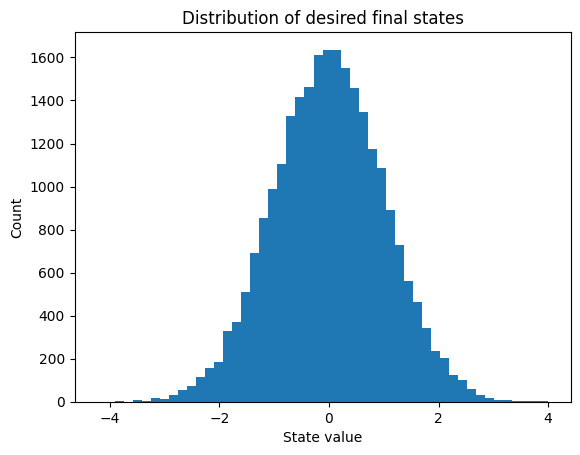

In [5]:
# Get statistics of the target states
print("Final-state statistics:")
print("Min :", Xf.min())
print("Max :", Xf.max())
print("Mean:", Xf.mean())
print("Std :", Xf.std())

# Plot distribution of the final states
plt.hist(Xf.flatten(), bins=50)
plt.xlabel("State value")
plt.ylabel("Count")
plt.title("Distribution of desired final states")
plt.show()

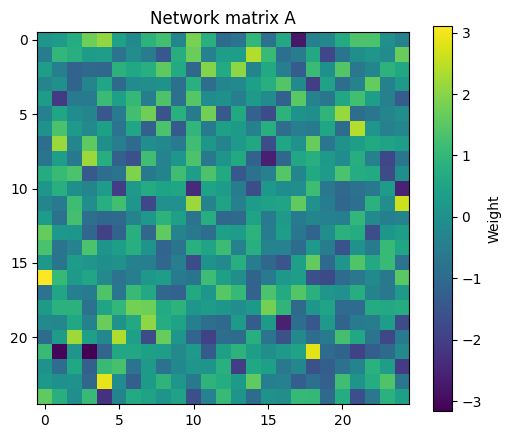

In [6]:
# Plot heatmap of dynamics matrix
plt.figure(figsize=(6,5))
plt.imshow(A)
plt.colorbar(label="Weight")
plt.title("Network matrix A")
plt.show()

### Dynamics Diagnostics

Spectral radius: 6.077790816533421
Nonzero entries: 625


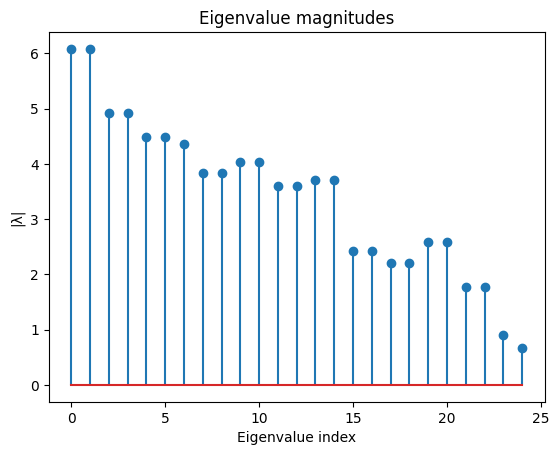

In [7]:
# Look at the eigenvalues of A
eigvals = np.linalg.eigvals(A)
print("Spectral radius:", np.max(np.abs(eigvals)))
print("Nonzero entries:", np.count_nonzero(A))

# Plot absolute value of eigenvalues
plt.stem(np.abs(eigvals))
plt.xlabel("Eigenvalue index")
plt.ylabel("|λ|")
plt.title("Eigenvalue magnitudes")
plt.show()

In [8]:
# Check sparsity condition
N = A.shape[0]
rank_A = np.linalg.matrix_rank(A)
s_min = N - rank_A
print("rank(A):", rank_A)
print("s_min = N - rank(A):", s_min)

rank(A): 25
s_min = N - rank(A): 0


## Problem Formulation

In [9]:
# Define horizon and target
T = N

# Set target
x0 = np.zeros(N)
Y = Xf.copy()   # since x0 = 0, y = xd = Xf

# Build controllability matrix
C = build_C(A, T)

print("N:", N)
print("T:", T)
print("Y shape:", Y.shape)
print("C shape:", C.shape)

N: 25
T: 25
Y shape: (1000, 25)
C shape: (25, 625)


In [11]:
# Check conditioning of C
matrix_diagnostics(C, "Raw C")

Raw C
-----
Rank: 21
Largest singular value : 1.1174196847852622e+19
Smallest singular value: 154.67653068923332
Condition number: 7.224235504934578e+16



In [11]:
# Normalize colums by their maximum value
col_norms = np.linalg.norm(C, axis=0)
safe_col_norms = np.maximum(col_norms, 1e-12)

C_tilde = C / safe_col_norms[None, :]

# Print diagnostics
print("Column norm range before normalization:")
print("min:", col_norms.min())
print("max:", col_norms.max())
print("\nColumn norm range after normalization:")
print("min:", np.linalg.norm(C_tilde, axis=0).min())
print("max:", np.linalg.norm(C_tilde, axis=0).max())
print('\n')
matrix_diagnostics(C_tilde, "Normalized C_tilde")

Column norm range before normalization:
min: 1.0
max: 4.5173382660303775e+18

Column norm range after normalization:
min: 0.9999999999999997
max: 1.0000000000000002


Normalized C_tilde
------------------
Rank: 25
Largest singular value : 16.70183444149045
Smallest singular value: 1.0017891014191829
Condition number: 16.67200653094531



In [14]:
# Check coherence of the matrix
G = C_tilde.T @ C_tilde # columns already unit-norm
mu = np.max(np.abs(G))
print("Mutual coherence of C_tilde:", mu)

Mutual coherence of C_tilde: 1.0000000000000007


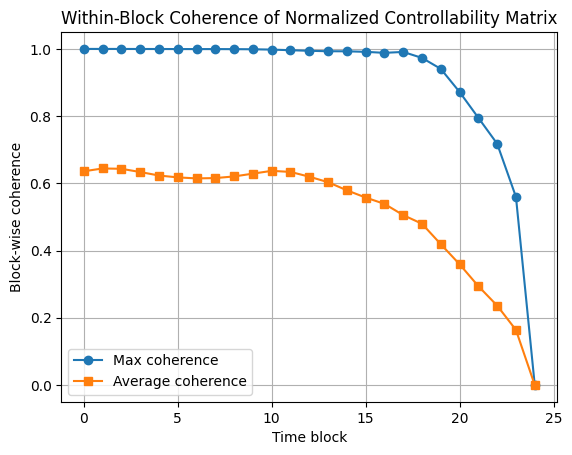

In [193]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes C_tilde has shape (N, N*T)
N = 25
T = 25

max_block_mu = []
avg_block_mu = []

for t in range(T):
    cols = slice(t*N, (t+1)*N)
    Ct = C_tilde[:, cols]

    Gt = np.abs(Ct.T @ Ct)
    np.fill_diagonal(Gt, 0)

    max_block_mu.append(np.max(Gt))
    avg_block_mu.append(np.sum(Gt) / (N * (N - 1)))

plt.figure()
plt.plot(max_block_mu, marker='o', label='Max coherence')
plt.plot(avg_block_mu, marker='s', label='Average coherence')
plt.xlabel('Time block')
plt.ylabel('Block-wise coherence')
plt.title('Within-Block Coherence of Normalized Controllability Matrix')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Check least-squares solution as a sanity check
ls_sanity_check(C, C_tilde, safe_col_norms, Y)

Least-squares sanity check
--------------------------
Raw C mean error: 0.388202036642923
Normalized mean error: 2.8600722379911065e-15
Raw C max error: 0.6757882435561858
Normalized max error: 4.1138692772606135e-15


## OMP Baseline

In [ ]:
# OMP sparsity sweep
s_values = [1, 2, 3, 4, 5]
omp_results = {}

# Evaluate OMP for the different final states
for s in s_values:
    res = evaluate_omp(Xf, C, C_tilde, safe_col_norms, s, N=N, T=T)
    omp_results[s] = res
    print(f"\nOMP baseline, s={s}, K={T*s}")
    print("----------------------")
    print("Mean error :", res["errors"].mean())
    print("Median error:", np.median(res["errors"]))
    print("Max error  :", res["errors"].max())
    print("Mean energy:", res["energies"].mean())


OMP baseline, s=1, K=25
----------------------
Mean error : 1.4264949534931928e-15
Median error: 1.1105910798147115e-15
Max error  : 1.1700952846897371e-14
Mean energy: 4.35940022845141

OMP baseline, s=2, K=50
----------------------
Mean error : 1.9372857772677202e-15
Median error: 1.5934049583477887e-15
Max error  : 1.1472554353967066e-14
Mean energy: 3.621172484661528

OMP baseline, s=3, K=75
----------------------
Mean error : 2.018476767007625e-15
Median error: 1.6567542760890741e-15
Max error  : 1.4102465860387549e-14
Mean energy: 3.2671482691756446

OMP baseline, s=4, K=100
----------------------
Mean error : 2.1176259851233167e-15
Median error: 1.7245932859247289e-15
Max error  : 1.498863041523547e-14
Mean energy: 3.0709342471903516

OMP baseline, s=5, K=125
----------------------
Mean error : 2.087585755564852e-15
Median error: 1.7511330663191714e-15
Max error  : 1.2264503162787542e-14
Mean energy: 2.946712705998691


In [ ]:
# Block sparsity diagnostics
for s in s_values:
    block_counts = block_sparsity_counts(omp_results[s]["U_hat"], N=N, T=T)
    print(f"\nOMP block distribution, s={s}")
    print("---------------------------")
    print("Mean total sparsity:", block_counts.sum(axis=1).mean())
    print("Mean block sparsity:", block_counts.mean())
    print("Mean max block sparsity:", block_counts.max(axis=1).mean())
    print("Mean active block fraction:", np.mean(block_counts > 0))


OMP block distribution, s=1
---------------------------
Mean total sparsity: 24.999
Mean block sparsity: 0.99996
Mean max block sparsity: 19.433
Mean active block fraction: 0.15952

OMP block distribution, s=2
---------------------------
Mean total sparsity: 49.745
Mean block sparsity: 1.9898
Mean max block sparsity: 20.458
Mean active block fraction: 0.35056

OMP block distribution, s=3
---------------------------
Mean total sparsity: 73.569
Mean block sparsity: 2.94276
Mean max block sparsity: 21.114
Mean active block fraction: 0.4116

OMP block distribution, s=4
---------------------------
Mean total sparsity: 96.775
Mean block sparsity: 3.871
Mean max block sparsity: 21.951
Mean active block fraction: 0.4468

OMP block distribution, s=5
---------------------------
Mean total sparsity: 119.561
Mean block sparsity: 4.78244
Mean max block sparsity: 22.893
Mean active block fraction: 0.4696


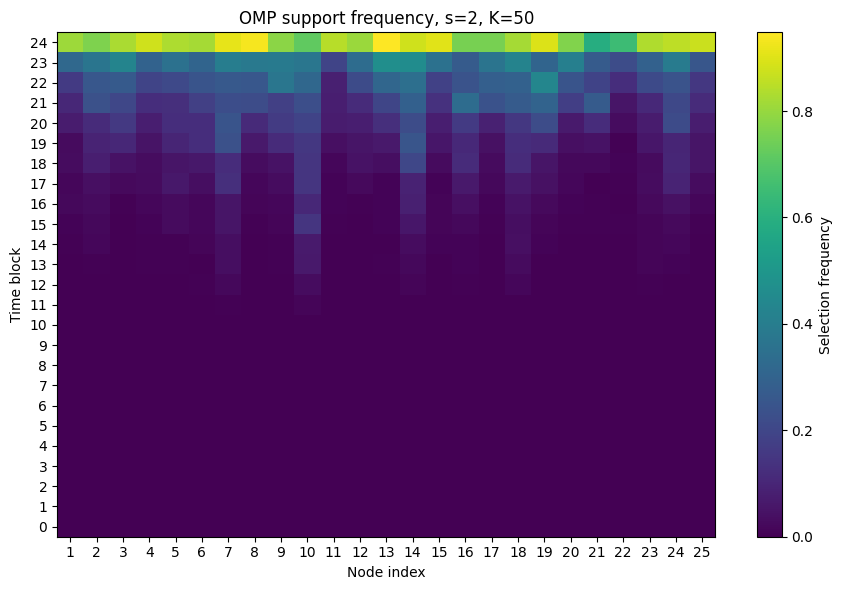

In [ ]:
# Get frequencies of the support
s = 2
_, omp_frequency = support_frequency_from_U(omp_results[s]["U_hat"], N=N, T=T)

# OMP support heatmap
plt.figure(figsize=(9, 6))
plt.imshow(omp_frequency, aspect="auto", origin="lower")
plt.colorbar(label="Selection frequency")
plt.xlabel("Node index")
plt.ylabel("Time block")
plt.title(f"OMP support frequency, s={s}, K={T*s}")
plt.xticks(np.arange(N), np.arange(1, N+1))
plt.yticks(np.arange(T), np.arange(T))
plt.tight_layout()
plt.show()

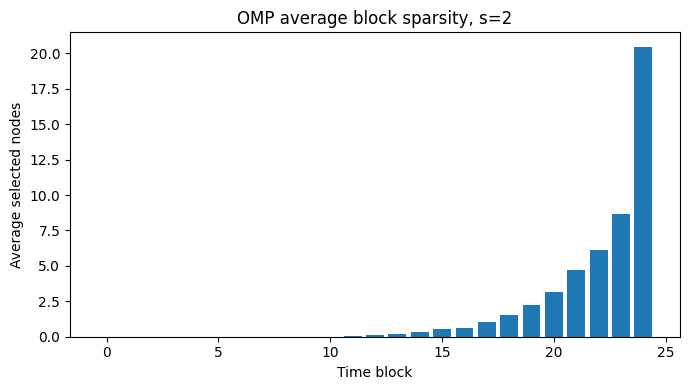

In [ ]:
# Average support per time block
omp_block_usage = omp_frequency.sum(axis=1)

# Plot distribution
plt.figure(figsize=(7, 4))
plt.bar(np.arange(T), omp_block_usage)
plt.xlabel("Time block")
plt.ylabel("Average selected nodes")
plt.title(f"OMP average block sparsity, s={s}")
plt.tight_layout()
plt.show()

## POMP Algorithm

In [214]:
# POMP sparsity sweep
s_values = [1, 2, 3, 4, 5]
pomp_results = {}

for s in s_values:
    res = evaluate_pomp(Xf, C, C_tilde, safe_col_norms, s, N=N, T=T)
    pomp_results[s] = res
    print(f"\nPOMP, s={s}")
    print("-----------")
    print("Mean error :", res["errors"].mean())
    print("Median error:", np.median(res["errors"]))
    print("Max error  :", res["errors"].max())
    print("Mean energy:", res["energies"].mean())


POMP, s=1
-----------
Mean error : 1.524636807382988e-08
Median error: 1.5899509834827092e-09
Max error  : 3.2074960862308963e-06
Mean energy: 57.04457257795559

POMP, s=2
-----------
Mean error : 1.0358524070530953e-13
Median error: 6.48158196220386e-14
Max error  : 1.5286562730199153e-12
Mean energy: 10.194752424016153

POMP, s=3
-----------
Mean error : 9.168900199116537e-15
Median error: 7.382903327278192e-15
Max error  : 1.5547687021895636e-13
Mean energy: 7.962602457413085

POMP, s=4
-----------
Mean error : 4.158063911221881e-15
Median error: 3.6817516770849e-15
Max error  : 1.8964010864153693e-14
Mean energy: 6.5780748496226185

POMP, s=5
-----------
Mean error : 3.340619015290686e-15
Median error: 2.9433001470491525e-15
Max error  : 1.0963947718093174e-14
Mean energy: 5.768571171005437


In [ ]:
# Verify piecewise constraint
for s in s_values:
    block_counts = block_sparsity_counts(pomp_results[s]["U_hat"], N=N, T=T)
    print(f"\nPOMP block distribution, s={s}")
    print("----------------------------")
    print("Mean total sparsity:", block_counts.sum(axis=1).mean())
    print("Mean block sparsity:", block_counts.mean())
    print("Mean max block sparsity:", block_counts.max(axis=1).mean())
    print("Largest observed block sparsity:", block_counts.max())


POMP block distribution, s=1
----------------------------
Mean total sparsity: 22.318
Mean block sparsity: 0.89272
Mean max block sparsity: 1.0
Largest observed block sparsity: 1

POMP block distribution, s=2
----------------------------
Mean total sparsity: 32.887
Mean block sparsity: 1.31548
Mean max block sparsity: 2.0
Largest observed block sparsity: 2

POMP block distribution, s=3
----------------------------
Mean total sparsity: 43.686
Mean block sparsity: 1.74744
Mean max block sparsity: 3.0
Largest observed block sparsity: 3

POMP block distribution, s=4
----------------------------
Mean total sparsity: 54.605
Mean block sparsity: 2.1842
Mean max block sparsity: 4.0
Largest observed block sparsity: 4

POMP block distribution, s=5
----------------------------
Mean total sparsity: 65.34
Mean block sparsity: 2.6136
Mean max block sparsity: 5.0
Largest observed block sparsity: 5


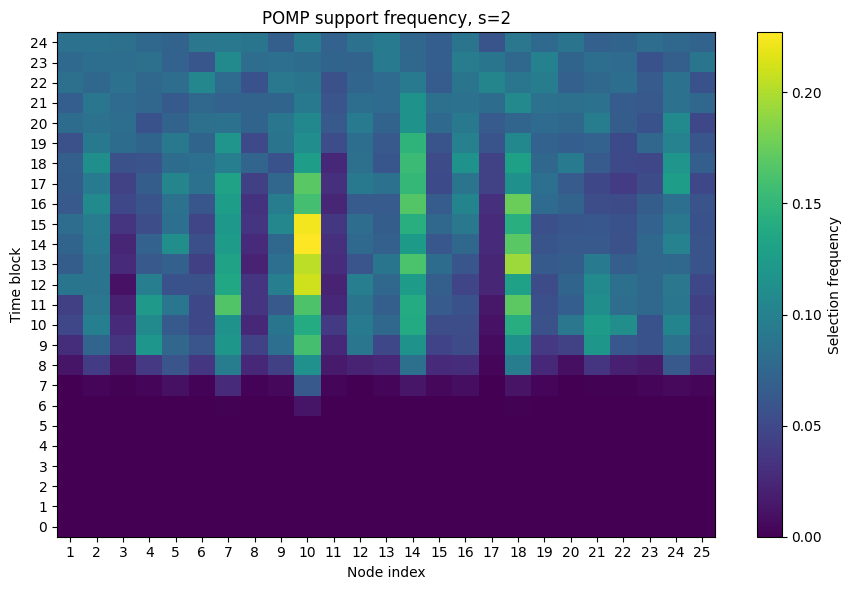

In [ ]:
# Get frequencies of the support
s = 2
_, pomp_frequency = support_frequency_from_U(pomp_results[s]["U_hat"], N=N, T=T)

# POMP support heatmap
plt.figure(figsize=(9, 6))
plt.imshow(pomp_frequency, aspect="auto", origin="lower")
plt.colorbar(label="Selection frequency")
plt.xlabel("Node index")
plt.ylabel("Time block")
plt.title(f"POMP support frequency, s={s}")
plt.xticks(np.arange(N), np.arange(1, N+1))
plt.yticks(np.arange(T), np.arange(T))
plt.tight_layout()
plt.show()

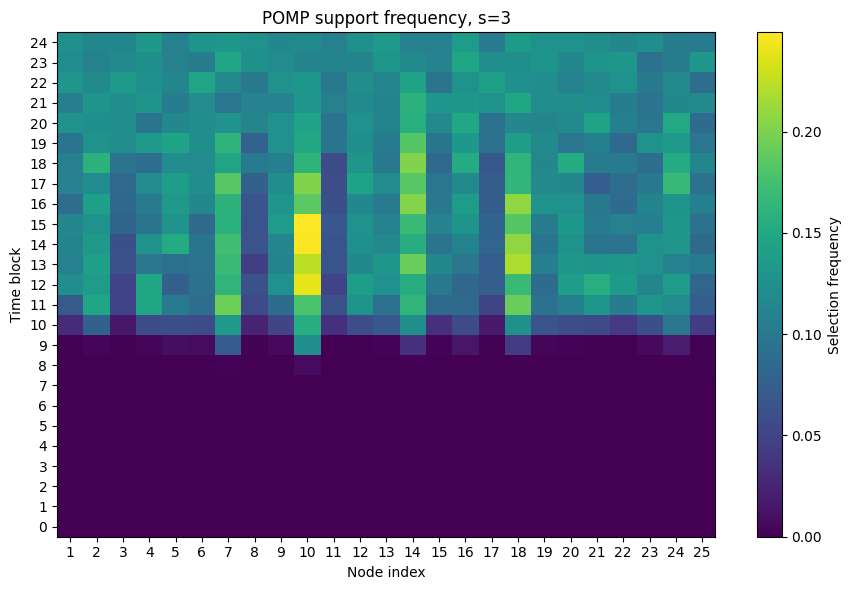

In [208]:
# Get frequencies of the support
s = 3
_, pomp_frequency = support_frequency_from_U(pomp_results[s]["U_hat"], N=N, T=T)

# POMP support heatmap
plt.figure(figsize=(9, 6))
plt.imshow(pomp_frequency, aspect="auto", origin="lower")
plt.colorbar(label="Selection frequency")
plt.xlabel("Node index")
plt.ylabel("Time block")
plt.title(f"POMP support frequency, s={s}")
plt.xticks(np.arange(N), np.arange(1, N+1))
plt.yticks(np.arange(T), np.arange(T))
plt.tight_layout()
plt.show()

## PSBL

In [200]:
s_values = [1, 2, 3, 4, 5]
sbl_results = {}

for s in s_values:
    res = evaluate_sbl_piecewise(Xf, C, C_tilde, safe_col_norms, s, N=N, T=T)
    sbl_results[s] = res

    print(f"\nPiecewise SBL, s={s}")
    print("----------------")
    print("Mean error :", res["errors"].mean())
    print("Median error:", np.median(res["errors"]))
    print("Max error  :", res["errors"].max())
    print("Mean energy:", res["energies"].mean())


Piecewise SBL, s=1
----------------
Mean error : 1.61388022355991e-08
Median error: 1.4250944557264575e-09
Max error  : 8.033969134805392e-06
Mean energy: 77.29645537355917

Piecewise SBL, s=2
----------------
Mean error : 1.2404565935223633e-13
Median error: 6.914939143966265e-14
Max error  : 2.759149159053683e-12
Mean energy: 7.9104578737929625

Piecewise SBL, s=3
----------------
Mean error : 7.156266949691045e-15
Median error: 5.574654657265947e-15
Max error  : 5.876534587317603e-14
Mean energy: 5.531493195303731

Piecewise SBL, s=4
----------------
Mean error : 3.729107027963578e-15
Median error: 3.132295150781006e-15
Max error  : 1.6016118848575668e-14
Mean energy: 4.550010479586096

Piecewise SBL, s=5
----------------
Mean error : 3.365973237222244e-15
Median error: 2.7009602831505724e-15
Max error  : 1.6159382304192633e-14
Mean energy: 4.121035256042761


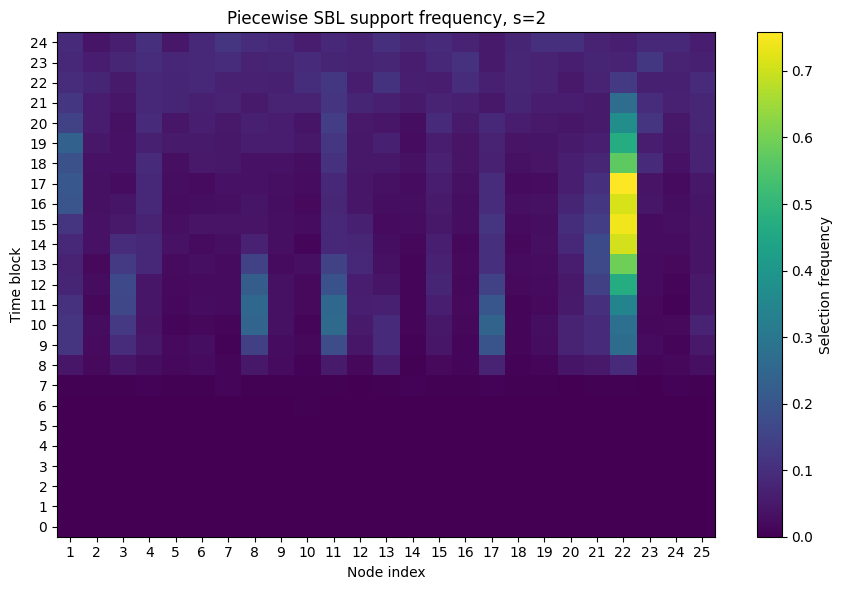

In [201]:
# Get frequencies of the support
s = 2
_, sbl_frequency = support_frequency_from_U(sbl_results[s]["U_hat"], N=N, T=T)

# SBL support heatmap
plt.figure(figsize=(9, 6))
plt.imshow(sbl_frequency, aspect="auto", origin="lower")
plt.colorbar(label="Selection frequency")
plt.xlabel("Node index")
plt.ylabel("Time block")
plt.title(f"Piecewise SBL support frequency, s={s}")
plt.xticks(np.arange(N), np.arange(1, N+1))
plt.yticks(np.arange(T), np.arange(T))
plt.tight_layout()
plt.show()

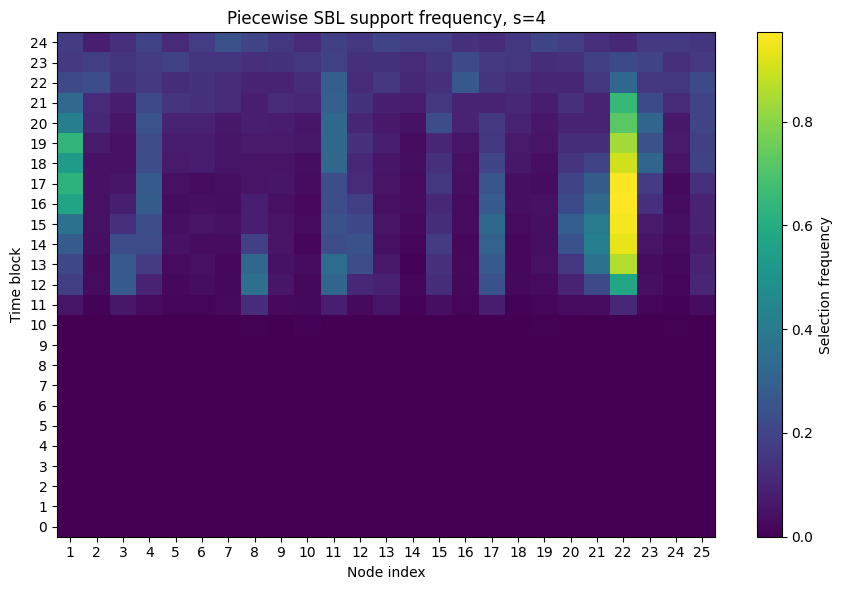

In [206]:
# Get frequencies of the support
s = 4
_, sbl_frequency = support_frequency_from_U(sbl_results[s]["U_hat"], N=N, T=T)

# SBL support heatmap
plt.figure(figsize=(9, 6))
plt.imshow(sbl_frequency, aspect="auto", origin="lower")
plt.colorbar(label="Selection frequency")
plt.xlabel("Node index")
plt.ylabel("Time block")
plt.title(f"Piecewise SBL support frequency, s={s}")
plt.xticks(np.arange(N), np.arange(1, N+1))
plt.yticks(np.arange(T), np.arange(T))
plt.tight_layout()
plt.show()

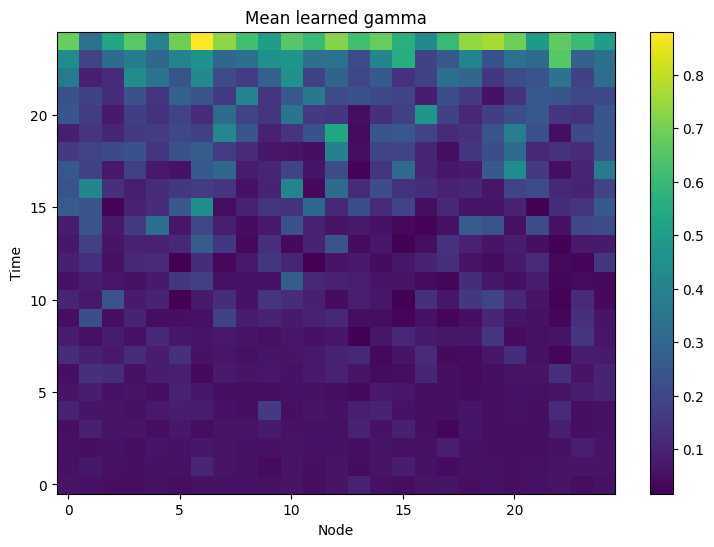

In [209]:
gamma_mean = np.mean(sbl_results[s]["gammas"], axis=0)
gamma_mean = gamma_mean.reshape(T, N)

plt.figure(figsize=(9,6))
plt.imshow(gamma_mean, aspect="auto", origin="lower")
plt.colorbar()
plt.title("Mean learned gamma")
plt.xlabel("Node")
plt.ylabel("Time")
plt.show()

In [210]:
# Verify piecewise constraint
for s in s_values:
    block_counts = block_sparsity_counts(sbl_results[s]["U_hat"], N=N, T=T)
    print(f"\nPOMP block distribution, s={s}")
    print("----------------------------")
    print("Mean total sparsity:", block_counts.sum(axis=1).mean())
    print("Mean block sparsity:", block_counts.mean())
    print("Mean max block sparsity:", block_counts.max(axis=1).mean())
    print("Largest observed block sparsity:", block_counts.max())


POMP block distribution, s=1
----------------------------
Mean total sparsity: 22.237
Mean block sparsity: 0.88948
Mean max block sparsity: 1.0
Largest observed block sparsity: 1

POMP block distribution, s=2
----------------------------
Mean total sparsity: 32.483
Mean block sparsity: 1.29932
Mean max block sparsity: 2.0
Largest observed block sparsity: 2

POMP block distribution, s=3
----------------------------
Mean total sparsity: 42.518
Mean block sparsity: 1.70072
Mean max block sparsity: 3.0
Largest observed block sparsity: 3

POMP block distribution, s=4
----------------------------
Mean total sparsity: 51.927
Mean block sparsity: 2.07708
Mean max block sparsity: 4.0
Largest observed block sparsity: 4

POMP block distribution, s=5
----------------------------
Mean total sparsity: 61.79
Mean block sparsity: 2.4716
Mean max block sparsity: 5.0
Largest observed block sparsity: 5
